# TP3 — Retrouver une loi de vieillissement à partir d'une Neural ODE

## Objectif

Dans le TP précédent, on a appris une **dynamique d'état** de vieillissement à partir de la tension mesurée :

$$
(SOC,T,I,D_C,D_R)
\longrightarrow
f_\theta
\longrightarrow
\left(
\frac{dD_C}{dQ},
\frac{dD_R}{dQ}
\right)
$$

Dans ce TP, on ne réentraîne pas la Neural ODE. On l'utilise comme un modèle continu déjà appris afin d'en extraire une loi explicite et interprétable avec **SINDy** :

Dans ce TP, on s'intéresse au **vieillissement de cyclage**. Le vieillissement calendaire est supposé connu et traité séparément.


## 1 Pourquoi appliquer SINDy après une Neural ODE ?

Une approche directe consisterait à estimer une dérivée à partir d'une trajectoire potentiellement bruitée :

$$
D(Q)
\longrightarrow
\frac{dD}{dQ}.
$$

Cette opération est sensible au bruit.

Ici, la Neural ODE apprise dans le TP précédent fournit directement un champ continu :

$$
\boxed{
f_\theta(SOC,T,I,D_C,D_R)
\approx
\begin{bmatrix}
dD_C/dQ\\
dD_R/dQ
\end{bmatrix}.
}
$$

On utilise donc le réseau comme un **surrogate continu et lissé**, puis on cherche une expression analytique simple qui l'approxime.

L'idée de SINDy est de supposer que la dynamique peut être décrite avec seulement quelques termes parmi une bibliothèque plus large :

$$
\frac{dD}{dQ}
=
\Theta(SOC,T,I,D_C,D_R)\,\xi.
$$

La matrice $\Theta$ contient les fonctions candidates et le vecteur $\xi$ leurs coefficients.

On cherche ensuite une solution **parcimonieuse**, c'est-à-dire avec peu de coefficients non nuls.


In [1]:
%pip install -q equinox pysindy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.8 MB/s eta 0:00:00


In [2]:

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import equinox as eqx

import pysindy as ps

print("JAX :", jax.__version__)
print("Equinox :", eqx.__version__)
print("PySINDy :", ps.__version__)


JAX : 0.11.1
Equinox : 0.13.8
PySINDy : 2.1.0


In [35]:
import sympy as sp # pour afficher les formules de manière symbolique
from IPython.display import display

# 2 Recharger la Neural ODE du TP précédent




In [3]:

import json
from pathlib import Path


WEIGHTS_URL = (
    "https://github.com/lilredhood/"
    "FakeBatteryData/releases/download/"
    "tp3-v1/fleet_ageing_neural_ode.eqx"
)

METADATA_URL = (
    "https://github.com/lilredhood/"
    "FakeBatteryData/releases/download/"
    "tp3-v1/fleet_ageing_neural_ode_metadata.json"
)


!wget -q --show-progress \
    "$WEIGHTS_URL" \
    -O fleet_ageing_neural_ode.eqx

!wget -q --show-progress \
    "$METADATA_URL" \
    -O fleet_ageing_neural_ode_metadata.json


MODEL_WEIGHTS_PATH = Path(
    "fleet_ageing_neural_ode.eqx"
)

MODEL_METADATA_PATH = Path(
    "fleet_ageing_neural_ode_metadata.json"
)


with open(
    MODEL_METADATA_PATH,
    "r",
    encoding="utf-8",
) as f:
    metadata = json.load(f)


print(
    "Poids :",
    MODEL_WEIGHTS_PATH
)

print(
    "Métadonnées :",
    MODEL_METADATA_PATH
)

print(metadata)

fleet_ageing_neural 100%[===================>]   2.32K  --.-KB/s    in 0s      
fleet_ageing_neural 100%[===================>]     953  --.-KB/s    in 0s      
Poids : fleet_ageing_neural_ode.eqx
Métadonnées : fleet_ageing_neural_ode_metadata.json
{'model': 'AgeingNN', 'inputs': ['SOC', 'T_scaled=(T-25)/20', 'I_scaled=abs(I)/200', 'D_C_scaled=D_C_total/0.05', 'D_R_scaled=D_R_total/0.10'], 'outputs': ['dD_C_cyc/dQ', 'dD_R_cyc/dQ'], 'architecture': {'in_size': 5, 'out_size': 2, 'width_size': 16, 'depth': 2, 'activation': 'tanh', 'positive_output': 'softplus'}, 'damage_reference': {'D_C_REF': 0.05, 'D_R_REF': 0.1}, 'rate_scale_C': 2e-05, 'rate_scale_R': 5e-05, 'trained_on_vehicles': ['A', 'B', 'C', 'D'], 'true_synthetic_law': {'kC_true': 1.0175042459741235e-05, 'kR_true': 2.692935890518129e-05, 'coeff_C': {'constant': 1.0, 'SOC': 1.0, 'T_scaled': 0.5, 'I_scaled': 0.5, 'D_C_scaled': 0.5}, 'coeff_R': {'constant': 1.0, 'SOC': 0.5, 'T_scaled': 0.5, 'I_scaled': 1.0, 'D_R_scaled': 0.5}}}


In [4]:
D_C_REF = float(
    metadata["damage_reference"]["D_C_REF"]
)

D_R_REF = float(
    metadata["damage_reference"]["D_R_REF"]
)

IN_SIZE = int(
    metadata["architecture"]["in_size"]
)

if IN_SIZE != 5:
    raise ValueError(
        "Les poids chargés correspondent à une ancienne Neural ODE. "
        "Le TP3 attend maintenant 5 entrées : "
        "SOC, T, I, D_C et D_R."
    )


class AgeingNN(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, key):
        self.mlp = eqx.nn.MLP(
            in_size=5,
            out_size=2,
            width_size=16,
            depth=2,
            activation=jax.nn.tanh,
            key=key,
        )

    def __call__(
        self,
        soc,
        temp,
        current,
        D_C_total,
        D_R_total,
    ):
        x = jnp.array([
            soc,
            (temp - 25.0) / 20.0,
            jnp.abs(current) / 200.0,
            D_C_total / D_C_REF,
            D_R_total / D_R_REF,
        ])

        raw = self.mlp(x)

        return jax.nn.softplus(raw)


RATE_SCALE_C = float(
    metadata["rate_scale_C"]
)

RATE_SCALE_R = float(
    metadata["rate_scale_R"]
)

key = jax.random.PRNGKey(0)

template = AgeingNN(key)

model = eqx.tree_deserialise_leaves(
    MODEL_WEIGHTS_PATH,
    template,
)

print("Neural ODE rechargée.")
print("D_C_REF =", D_C_REF)
print("D_R_REF =", D_R_REF)


Neural ODE rechargée.
D_C_REF = 0.05
D_R_REF = 0.1


## 2.1 Interroger le champ appris

La Neural ODE reçoit maintenant l'état instantané **et** l'état de vieillissement :

$$
(SOC,T,I,D_C,D_R)
\longrightarrow
f_\theta
$$

Les sorties du réseau sont ensuite remises à l'échelle pour obtenir les deux vitesses physiques :

$$
\frac{dD_C}{dQ}
\qquad
\frac{dD_R}{dQ}
$$



In [23]:
DISPLAY_RATE_SCALE = 100000.0


def ageing_rates_one(
    model,
    soc,
    temp,
    current,
    D_C,
    D_R,
):
    raw_rates = model(
        soc,
        temp,
        current,
        D_C,
        D_R,
    )

    return jnp.array([
        RATE_SCALE_C * raw_rates[0],
        RATE_SCALE_R * raw_rates[1],
    ])


ageing_rates_batch = eqx.filter_jit(
    jax.vmap(
        ageing_rates_one,
        in_axes=(
            None,
            0,
            0,
            0,
            0,
            0,
        ),
    )
)


test_rate = np.asarray(
    ageing_rates_one(
        model,
        0.6,
        30.0,
        100.0,
        0.025,
        0.050,
    )
)

print(
    "État test : "
    "SOC=0.6, T=30°C, |I|=100 A, "
    "D_C=0.025, D_R=0.050"
)

print(
    "Taux capacité redimensionné :",
    DISPLAY_RATE_SCALE * test_rate[0],
)

print(
    "Taux résistance redimensionné :",
    DISPLAY_RATE_SCALE * test_rate[1],
)


État test : SOC=0.6, T=30°C, |I|=100 A, D_C=0.025, D_R=0.050
Taux capacité redimensionné : 2.3156443
Taux résistance redimensionné : 5.9094644


# 3 — Observer la loi apprise avant de faire SINDy

On fait varier une variable à la fois autour d'un état de référence :

$$
SOC=0.6
\qquad
T=25^\circ C
\qquad
|I|=100~A
$$

$$
D_C=0.025
\qquad
D_R=0.050
$$

On regarde d'abord l'influence des sollicitations $(SOC,T,I)$, puis l'influence directe des états de dommage.

Les taux sont affichés sous une forme redimensionnée afin d'éviter des valeurs numériques inutilement petites sur les figures.


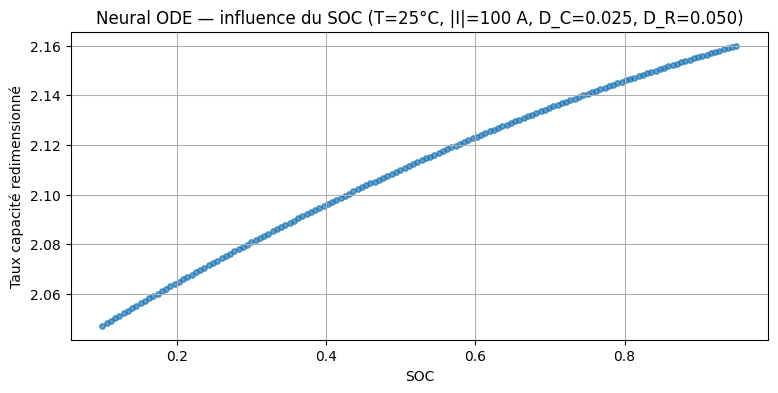

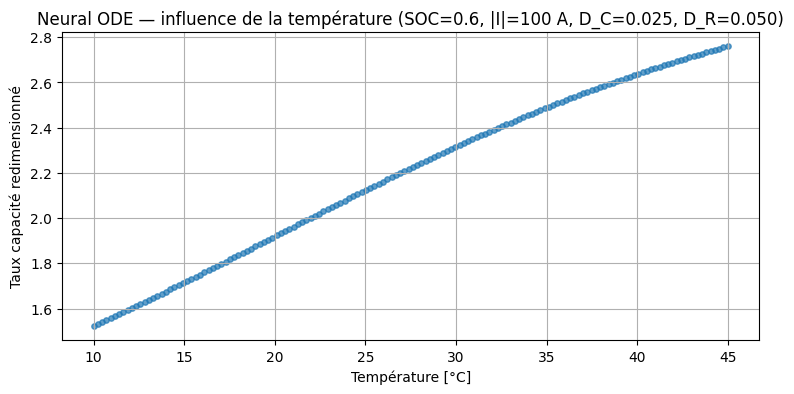

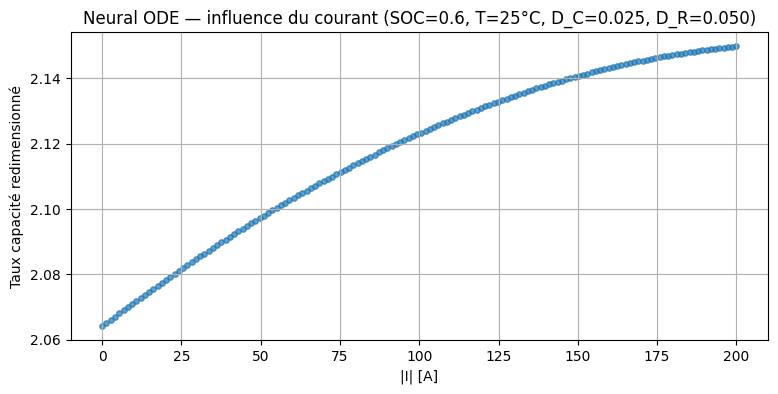

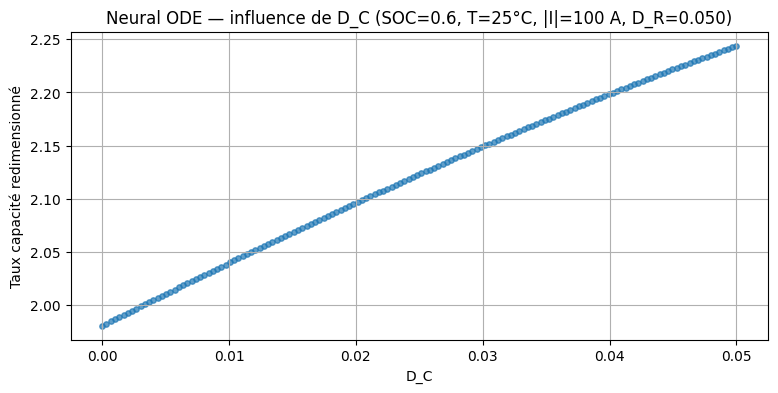

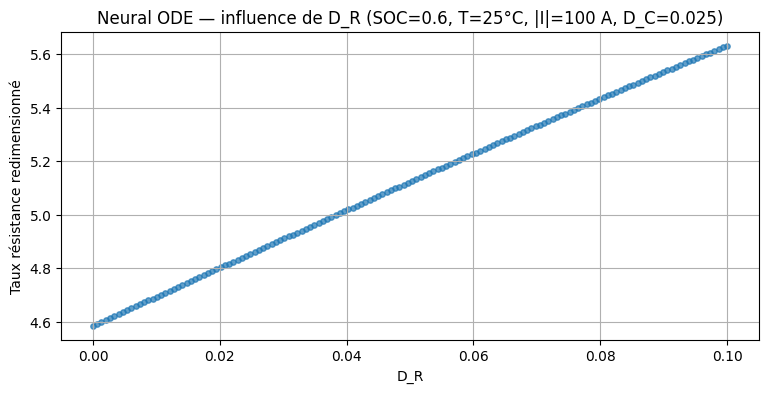

In [24]:
N_SLICE = 150

SOC_REF_PLOT = 0.60
TEMP_REF_PLOT = 25.0
CURRENT_REF_PLOT = 100.0
DC_REF_PLOT = 0.025
DR_REF_PLOT = 0.050


def evaluate_slice(
    soc,
    temp,
    current,
    D_C,
    D_R,
):
    return np.asarray(
        ageing_rates_batch(
            model,
            jnp.asarray(soc),
            jnp.asarray(temp),
            jnp.asarray(current),
            jnp.asarray(D_C),
            jnp.asarray(D_R),
        )
    )


# ============================================================
# 1. EFFET DU SOC
# ============================================================

soc_slice = np.linspace(
    0.1,
    0.95,
    N_SLICE,
)

rates_soc = evaluate_slice(
    soc_slice,
    np.full(N_SLICE, TEMP_REF_PLOT),
    np.full(N_SLICE, CURRENT_REF_PLOT),
    np.full(N_SLICE, DC_REF_PLOT),
    np.full(N_SLICE, DR_REF_PLOT),
)

plt.figure(figsize=(9, 4))
plt.scatter(
    soc_slice,
    DISPLAY_RATE_SCALE * rates_soc[:, 0],
    s=15,
    alpha=0.7,
)
plt.xlabel("SOC")
plt.ylabel("Taux capacité redimensionné")
plt.title(
    "Neural ODE — influence du SOC "
    "(T=25°C, |I|=100 A, D_C=0.025, D_R=0.050)"
)
plt.grid(True)
plt.show()


# ============================================================
# 2. EFFET DE LA TEMPÉRATURE
# ============================================================

temp_slice = np.linspace(
    10.0,
    45.0,
    N_SLICE,
)

rates_temp = evaluate_slice(
    np.full(N_SLICE, SOC_REF_PLOT),
    temp_slice,
    np.full(N_SLICE, CURRENT_REF_PLOT),
    np.full(N_SLICE, DC_REF_PLOT),
    np.full(N_SLICE, DR_REF_PLOT),
)

plt.figure(figsize=(9, 4))
plt.scatter(
    temp_slice,
    DISPLAY_RATE_SCALE * rates_temp[:, 0],
    s=15,
    alpha=0.7,
)
plt.xlabel("Température [°C]")
plt.ylabel("Taux capacité redimensionné")
plt.title(
    "Neural ODE — influence de la température "
    "(SOC=0.6, |I|=100 A, D_C=0.025, D_R=0.050)"
)
plt.grid(True)
plt.show()


# ============================================================
# 3. EFFET DU COURANT
# ============================================================

current_slice = np.linspace(
    0.0,
    200.0,
    N_SLICE,
)

rates_current = evaluate_slice(
    np.full(N_SLICE, SOC_REF_PLOT),
    np.full(N_SLICE, TEMP_REF_PLOT),
    current_slice,
    np.full(N_SLICE, DC_REF_PLOT),
    np.full(N_SLICE, DR_REF_PLOT),
)

plt.figure(figsize=(9, 4))
plt.scatter(
    current_slice,
    DISPLAY_RATE_SCALE * rates_current[:, 0],
    s=15,
    alpha=0.7,
)
plt.xlabel("|I| [A]")
plt.ylabel("Taux capacité redimensionné")
plt.title(
    "Neural ODE — influence du courant "
    "(SOC=0.6, T=25°C, D_C=0.025, D_R=0.050)"
)
plt.grid(True)
plt.show()


# ============================================================
# 4. EFFET DE D_C SUR LA CAPACITÉ
# ============================================================

dc_slice = np.linspace(
    0.0,
    D_C_REF,
    N_SLICE,
)

rates_dc = evaluate_slice(
    np.full(N_SLICE, SOC_REF_PLOT),
    np.full(N_SLICE, TEMP_REF_PLOT),
    np.full(N_SLICE, CURRENT_REF_PLOT),
    dc_slice,
    np.full(N_SLICE, DR_REF_PLOT),
)

plt.figure(figsize=(9, 4))
plt.scatter(
    dc_slice,
    DISPLAY_RATE_SCALE * rates_dc[:, 0],
    s=15,
    alpha=0.7,
)
plt.xlabel("D_C")
plt.ylabel("Taux capacité redimensionné")
plt.title(
    "Neural ODE — influence de D_C "
    "(SOC=0.6, T=25°C, |I|=100 A, D_R=0.050)"
)
plt.grid(True)
plt.show()


# ============================================================
# 5. EFFET DE D_R SUR LA RÉSISTANCE
# ============================================================

dr_slice = np.linspace(
    0.0,
    D_R_REF,
    N_SLICE,
)

rates_dr = evaluate_slice(
    np.full(N_SLICE, SOC_REF_PLOT),
    np.full(N_SLICE, TEMP_REF_PLOT),
    np.full(N_SLICE, CURRENT_REF_PLOT),
    np.full(N_SLICE, DC_REF_PLOT),
    dr_slice,
)

plt.figure(figsize=(9, 4))
plt.scatter(
    dr_slice,
    DISPLAY_RATE_SCALE * rates_dr[:, 1],
    s=15,
    alpha=0.7,
)
plt.xlabel("D_R")
plt.ylabel("Taux résistance redimensionné")
plt.title(
    "Neural ODE — influence de D_R "
    "(SOC=0.6, T=25°C, |I|=100 A, D_C=0.025)"
)
plt.grid(True)
plt.show()


# 4 — Construire un jeu de données à partir de la Neural ODE

Le réseau est déjà appris : on peut maintenant l'interroger dans son domaine de fonctionnement.

On tire des états dans les intervalles :

$$
SOC\in[0.1,0.95]
\qquad
T\in[10,45]^\circ C
\qquad
|I|\in[0,200]~A
$$

$$
D_C\in[0,D_{C,\mathrm{ref}}]
\qquad
D_R\in[0,D_{R,\mathrm{ref}}]
$$

On utilise les mêmes variables normalisées que dans la Neural ODE :

$$
\widetilde T=\frac{T-25}{20}
\qquad
\widetilde I=\frac{|I|}{200}
$$

$$
\widetilde D_C=\frac{D_C}{D_{C,\mathrm{ref}}}
\qquad
\widetilde D_R=\frac{D_R}{D_{R,\mathrm{ref}}}
$$


In [25]:
rng = np.random.default_rng(42)

N_SAMPLES = 12000

SOC_samples = rng.uniform(
    0.1,
    0.95,
    N_SAMPLES,
)

T_samples = rng.uniform(
    10.0,
    45.0,
    N_SAMPLES,
)

I_samples = rng.uniform(
    0.0,
    200.0,
    N_SAMPLES,
)

D_C_samples = rng.uniform(
    0.0,
    D_C_REF,
    N_SAMPLES,
)

D_R_samples = rng.uniform(
    0.0,
    D_R_REF,
    N_SAMPLES,
)

rates_phys = np.asarray(
    ageing_rates_batch(
        model,
        jnp.asarray(SOC_samples),
        jnp.asarray(T_samples),
        jnp.asarray(I_samples),
        jnp.asarray(D_C_samples),
        jnp.asarray(D_R_samples),
    )
)

# Cibles redimensionnées pour SINDy
rate_C = (
    DISPLAY_RATE_SCALE
    * rates_phys[:, 0]
)

rate_R = (
    DISPLAY_RATE_SCALE
    * rates_phys[:, 1]
)

T_scaled = (
    T_samples - 25.0
) / 20.0

I_scaled = (
    I_samples / 200.0
)

D_C_scaled = (
    D_C_samples / D_C_REF
)

D_R_scaled = (
    D_R_samples / D_R_REF
)

X = np.column_stack([
    SOC_samples,
    T_scaled,
    I_scaled,
    D_C_scaled,
    D_R_scaled,
])

perm = rng.permutation(
    N_SAMPLES
)

n_train = int(
    0.75 * N_SAMPLES
)

idx_train = perm[:n_train]
idx_test = perm[n_train:]

X_train = X[idx_train]
X_test = X[idx_test]

yC_train = rate_C[idx_train]
yC_test = rate_C[idx_test]

yR_train = rate_R[idx_train]
yR_test = rate_R[idx_test]

print("Points SINDy train :", len(idx_train))
print("Points SINDy test  :", len(idx_test))


Points SINDy train : 9000
Points SINDy test  : 3000


# 5 — Premier essai : bibliothèque minimale

On commence par une bibliothèque commune aux deux sorties :

$$
\boxed{
\Theta
=
\begin{bmatrix}
1 &
SOC &
\widetilde T &
\widetilde I &
\widetilde D_C &
\widetilde D_R
\end{bmatrix}
$$

On cherche donc une loi de la forme :

$$
r^\star
=
\xi_0
+\xi_1SOC
+\xi_2\widetilde T
+\xi_3\widetilde I
+\xi_4\widetilde D_C
+\xi_5\widetilde D_R
$$

Avant d'introduire SINDy, on résout simplement le problème par moindres carrés.


In [26]:
FEATURE_NAMES_SIMPLE = [
    "1",
    "SOC",
    "T_tilde",
    "I_tilde",
    "D_C_tilde",
    "D_R_tilde",
]


def library_simple(X):
    return np.column_stack([
        np.ones(len(X)),
        X[:, 0],
        X[:, 1],
        X[:, 2],
        X[:, 3],
        X[:, 4],
    ])


Theta_train_simple = library_simple(
    X_train
)

Theta_test_simple = library_simple(
    X_test
)

coef_C_lstsq = np.linalg.lstsq(
    Theta_train_simple,
    yC_train,
    rcond=None,
)[0]

coef_R_lstsq = np.linalg.lstsq(
    Theta_train_simple,
    yR_train,
    rcond=None,
)[0]


def print_law(
    title,
    names,
    coef,
):
    print(title)

    for name, value in zip(
        names,
        coef,
    ):
        print(
            f"  {name:14s} : "
            f"{value:+.4f}"
        )


print_law(
    "Loi capacité — moindres carrés",
    FEATURE_NAMES_SIMPLE,
    coef_C_lstsq,
)

print()

print_law(
    "Loi résistance — moindres carrés",
    FEATURE_NAMES_SIMPLE,
    coef_R_lstsq,
)


Loi capacité — moindres carrés
  1              : +1.7172
  SOC            : +0.1303
  T_tilde        : +0.7238
  I_tilde        : +0.0938
  D_C_tilde      : +0.2373
  D_R_tilde      : +0.2540

Loi résistance — moindres carrés
  1              : +3.9227
  SOC            : +0.1483
  T_tilde        : +2.9006
  I_tilde        : +0.3088
  D_C_tilde      : +0.9040
  D_R_tilde      : +0.9615


In [27]:
def regression_metrics(
    y_true,
    y_pred,
):
    rmse = np.sqrt(
        np.mean(
            (
                y_true
                - y_pred
            )**2
        )
    )

    nrmse = (
        rmse
        / np.std(y_true)
    )

    r2 = (
        1.0
        - np.sum(
            (
                y_true
                - y_pred
            )**2
        )
        / np.sum(
            (
                y_true
                - np.mean(y_true)
            )**2
        )
    )

    return rmse, nrmse, r2


pred_C_lstsq = (
    Theta_test_simple
    @ coef_C_lstsq
)

pred_R_lstsq = (
    Theta_test_simple
    @ coef_R_lstsq
)

metrics_C = regression_metrics(
    yC_test,
    pred_C_lstsq,
)

metrics_R = regression_metrics(
    yR_test,
    pred_R_lstsq,
)

print(
    "Capacité : "
    f"RMSE={metrics_C[0]:.4f}, "
    f"NRMSE={metrics_C[1]:.3f}, "
    f"R²={metrics_C[2]:.5f}"
)

print(
    "Résistance : "
    f"RMSE={metrics_R[0]:.4f}, "
    f"NRMSE={metrics_R[1]:.3f}, "
    f"R²={metrics_R[2]:.5f}"
)


Capacité : RMSE=0.0281, NRMSE=0.074, R²=0.99460
Résistance : RMSE=0.0660, NRMSE=0.044, R²=0.99810


In [28]:


SOC_sym = sp.Symbol("SOC")
T_sym = sp.Symbol(r"\widetilde{T}")
I_sym = sp.Symbol(r"\widetilde{I}")
DC_sym = sp.Symbol(r"\widetilde{D}_C")
DR_sym = sp.Symbol(r"\widetilde{D}_R")

terms = [
    1,
    SOC_sym,
    T_sym,
    I_sym,
    DC_sym,
    DR_sym,
]


def build_symbolic_law(
    coefficients,
    terms,
    n_digits=4,
):
    expr = 0

    for coef, term in zip(
        coefficients,
        terms,
    ):
        expr += (
            sp.Float(
                float(coef),
                n_digits,
            )
            * term
        )

    return sp.collect(
        expr,
        [
            SOC_sym,
            T_sym,
            I_sym,
            DC_sym,
            DR_sym,
        ],
    )


expr_C = build_symbolic_law(
    coef_C_lstsq,
    terms,
)

expr_R = build_symbolic_law(
    coef_R_lstsq,
    terms,
)

rC_star = sp.Symbol(r"r_C^\star")
rR_star = sp.Symbol(r"r_R^\star")

print("Loi identifiée pour la capacité :")
display(
    sp.Eq(
        rC_star,
        expr_C,
    )
)

print("Loi identifiée pour la résistance :")
display(
    sp.Eq(
        rR_star,
        expr_R,
    )
)


Loi identifiée pour la capacité :


Eq(r_C^\star, 0.1303*SOC + 0.2373*\widetilde{D}_C + 0.254*\widetilde{D}_R + 0.09377*\widetilde{I} + 0.7238*\widetilde{T} + 1.717)

Loi identifiée pour la résistance :


Eq(r_R^\star, 0.1483*SOC + 0.904*\widetilde{D}_C + 0.9615*\widetilde{D}_R + 0.3088*\widetilde{I} + 2.901*\widetilde{T} + 3.923)

# 6 Le cœur de SINDy : STLSQ

Une stratégie classique de SINDy est **STLSQ** :

**Sequentially Thresholded Least Squares**

Principe :

1. résoudre une régression
2. supprimer les coefficients dont la valeur absolue est inférieure à un seuil $\lambda$
3. refaire la régression avec les termes conservés
4. répéter jusqu'à stabilisation

Schématiquement :

$$
\xi^{(0)}
=
\arg\min_\xi
\left\|
\Theta\xi-y
\right\|_2^2
$$

puis :

$$
|\xi_j|<\lambda
\quad\Rightarrow\quad
\xi_j=0
$$



In [11]:
def stlsq(
    Theta,
    y,
    threshold=0.05,
    ridge=1.0e-8,
    n_iter=20,
):
    # Version pédagogique de STLSQ

    n_features = (
        Theta.shape[1]
    )

    A = (
        Theta.T @ Theta
        + ridge
        * np.eye(n_features)
    )

    b = (
        Theta.T @ y
    )

    xi = np.linalg.solve(
        A,
        b,
    )

    for _ in range(n_iter):
        active = (
            np.abs(xi)
            >= threshold
        )

        if not np.any(active):
            break

        xi_new = np.zeros_like(
            xi
        )

        xi_new[active] = (

            np.linalg.lstsq(
                Theta[:, active],
                y,
                rcond=None,
            )[0]
        )

        if np.allclose(
            xi,
            xi_new,
        ):
            xi = xi_new
            break

        xi = xi_new

    return xi


In [12]:
THRESHOLD = 0.05

coef_C_sindy = stlsq(
    Theta_train_simple,
    yC_train,
    threshold=THRESHOLD,
)

coef_R_sindy = stlsq(
    Theta_train_simple,
    yR_train,
    threshold=THRESHOLD,
)

print_law(
    "Loi SINDy — capacité",
    FEATURE_NAMES_SIMPLE,
    coef_C_sindy,
)

print()

print_law(
    "Loi SINDy — résistance",
    FEATURE_NAMES_SIMPLE,
    coef_R_sindy,
)


Loi SINDy — capacité
  1              : +1.7172
  SOC            : +0.1303
  T_tilde        : +0.7238
  I_tilde        : +0.0938
  D_C_tilde      : +0.2373
  D_R_tilde      : +0.2540

Loi SINDy — résistance
  1              : +3.9227
  SOC            : +0.1483
  T_tilde        : +2.9006
  I_tilde        : +0.3088
  D_C_tilde      : +0.9040
  D_R_tilde      : +0.9615


In [29]:
#@title Régression SINDy et lois symboliques

THRESHOLD = 0.05

coef_C_sindy = stlsq(
    Theta_train_simple,
    yC_train,
    threshold=THRESHOLD,
)

coef_R_sindy = stlsq(
    Theta_train_simple,
    yR_train,
    threshold=THRESHOLD,
)


expr_C_sindy = build_symbolic_law(
    coef_C_sindy,
    terms,
)

expr_R_sindy = build_symbolic_law(
    coef_R_sindy,
    terms,
)


rC_star = sp.Symbol(r"r_C^\star")
rR_star = sp.Symbol(r"r_R^\star")


print("Loi SINDy — capacité :")

display(
    sp.Eq(
        rC_star,
        expr_C_sindy,
    )
)


print("Loi SINDy — résistance :")

display(
    sp.Eq(
        rR_star,
        expr_R_sindy,
    )
)

Loi SINDy — capacité :


Eq(r_C^\star, 0.1303*SOC + 0.2373*\widetilde{D}_C + 0.254*\widetilde{D}_R + 0.09377*\widetilde{I} + 0.7238*\widetilde{T} + 1.717)

Loi SINDy — résistance :


Eq(r_R^\star, 0.1483*SOC + 0.904*\widetilde{D}_C + 0.9615*\widetilde{D}_R + 0.3088*\widetilde{I} + 2.901*\widetilde{T} + 3.923)


## 6.1 Même opération avec PySINDy

La cellule précédente permet de comprendre l'algorithme.

On peut ensuite utiliser directement l'optimiseur `STLSQ` fourni par PySINDy.


In [13]:
optimizer_C = ps.STLSQ(
    threshold=THRESHOLD,
    alpha=1.0e-8,
    max_iter=50,
)

optimizer_R = ps.STLSQ(
    threshold=THRESHOLD,
    alpha=1.0e-8,
    max_iter=50,
)

optimizer_C.fit(
    Theta_train_simple,
    yC_train,
)

optimizer_R.fit(
    Theta_train_simple,
    yR_train,
)

coef_C_pysindy = (
    np.asarray(
        optimizer_C.coef_
    ).reshape(-1)
)

coef_R_pysindy = (
    np.asarray(
        optimizer_R.coef_
    ).reshape(-1)
)

print_law(
    "PySINDy STLSQ — capacité",
    FEATURE_NAMES_SIMPLE,
    coef_C_pysindy,
)

print()

print_law(
    "PySINDy STLSQ — résistance",
    FEATURE_NAMES_SIMPLE,
    coef_R_pysindy,
)


PySINDy STLSQ — capacité
  1              : +1.7172
  SOC            : +0.1303
  T_tilde        : +0.7238
  I_tilde        : +0.0938
  D_C_tilde      : +0.2373
  D_R_tilde      : +0.2540

PySINDy STLSQ — résistance
  1              : +3.9227
  SOC            : +0.1483
  T_tilde        : +2.9006
  I_tilde        : +0.3088
  D_C_tilde      : +0.9040
  D_R_tilde      : +0.9615


In [34]:
#@title affichage symbolique

optimizer_C = ps.STLSQ(
    threshold=THRESHOLD,
    alpha=1.0e-8,
    max_iter=50,
)

optimizer_R = ps.STLSQ(
    threshold=THRESHOLD,
    alpha=1.0e-8,
    max_iter=50,
)

optimizer_C.fit(
    Theta_train_simple,
    yC_train,
)

optimizer_R.fit(
    Theta_train_simple,
    yR_train,
)

coef_C_pysindy = (
    np.asarray(
        optimizer_C.coef_
    ).reshape(-1)
)

coef_R_pysindy = (
    np.asarray(
        optimizer_R.coef_
    ).reshape(-1)
)


expr_C_pysindy = build_symbolic_law(
    coef_C_pysindy,
    terms,
)

expr_R_pysindy = build_symbolic_law(
    coef_R_pysindy,
    terms,
)


rC_star = sp.Symbol(r"r_C^\star")
rR_star = sp.Symbol(r"r_R^\star")


print("PySINDy STLSQ — capacité :")

display(
    sp.Eq(
        rC_star,
        expr_C_pysindy,
    )
)


print("PySINDy STLSQ — résistance :")

display(
    sp.Eq(
        rR_star,
        expr_R_pysindy,
    )
)

PySINDy STLSQ — capacité :


Eq(r_C^\star, 0.1303*SOC + 0.2373*\widetilde{D}_C + 0.254*\widetilde{D}_R + 0.09377*\widetilde{I} + 0.7238*\widetilde{T} + 1.717)

PySINDy STLSQ — résistance :


Eq(r_R^\star, 0.1483*SOC + 0.904*\widetilde{D}_C + 0.9615*\widetilde{D}_R + 0.3088*\widetilde{I} + 2.901*\widetilde{T} + 3.923)

# 7 bibliothèque volontairement trop riche

Dans un problème réel, on ne connaît pas la bonne structure.

On propose donc une bibliothèque contenant :

- les cinq variables $SOC$, $\widetilde T$, $\widetilde I$ $\widetilde D_C$, $\widetilde D_R$
- leurs carrés
- leurs produits deux à deux

La vraie loi synthétique est beaucoup plus simple. L'objectif de SINDy est donc de supprimer les termes inutiles.


In [31]:
BASE_FEATURE_NAMES = [
    "SOC",
    "T_tilde",
    "I_tilde",
    "D_C_tilde",
    "D_R_tilde",
]

PAIR_INDICES = [
    (0, 1),
    (0, 2),
    (0, 3),
    (0, 4),
    (1, 2),
    (1, 3),
    (1, 4),
    (2, 3),
    (2, 4),
    (3, 4),
]

FEATURE_NAMES_RICH = (
    ["1"]
    + BASE_FEATURE_NAMES
    + [
        f"{name}^2"
        for name in BASE_FEATURE_NAMES
    ]
    + [
        (
            f"{BASE_FEATURE_NAMES[i]}"
            f"*{BASE_FEATURE_NAMES[j]}"
        )
        for i, j in PAIR_INDICES
    ]
)


def library_rich(X):
    columns = [
        np.ones(len(X))
    ]

    # Termes linéaires
    for j in range(
        X.shape[1]
    ):
        columns.append(
            X[:, j]
        )

    # Carrés
    for j in range(
        X.shape[1]
    ):
        columns.append(
            X[:, j] ** 2
        )

    # Interactions deux à deux
    for i, j in PAIR_INDICES:
        columns.append(
            X[:, i]
            * X[:, j]
        )

    return np.column_stack(
        columns
    )


Theta_train_rich = library_rich(
    X_train
)

Theta_test_rich = library_rich(
    X_test
)

coef_C_rich = stlsq(
    Theta_train_rich,
    yC_train,
    threshold=THRESHOLD,
)

coef_R_rich = stlsq(
    Theta_train_rich,
    yR_train,
    threshold=THRESHOLD,
)

print_law(
    "Bibliothèque riche — capacité",
    FEATURE_NAMES_RICH,
    coef_C_rich,
)

print()

print_law(
    "Bibliothèque riche — résistance",
    FEATURE_NAMES_RICH,
    coef_R_rich,
)


Bibliothèque riche — capacité
  1              : +1.7160
  SOC            : +0.1866
  T_tilde        : +0.7769
  I_tilde        : +0.1532
  D_C_tilde      : +0.2447
  D_R_tilde      : +0.2547
  SOC^2          : -0.0542
  T_tilde^2      : -0.1008
  I_tilde^2      : -0.0591
  D_C_tilde^2    : +0.0000
  D_R_tilde^2    : +0.0000
  SOC*T_tilde    : +0.0000
  SOC*I_tilde    : +0.0000
  SOC*D_C_tilde  : +0.0000
  SOC*D_R_tilde  : +0.0000
  T_tilde*I_tilde : +0.0000
  T_tilde*D_C_tilde : -0.0559
  T_tilde*D_R_tilde : +0.0000
  I_tilde*D_C_tilde : +0.0000
  I_tilde*D_R_tilde : +0.0000
  D_C_tilde*D_R_tilde : +0.0000

Bibliothèque riche — résistance
  1              : +3.8185
  SOC            : +0.4275
  T_tilde        : +2.9275
  I_tilde        : +0.5096
  D_C_tilde      : +0.9050
  D_R_tilde      : +1.0769
  SOC^2          : -0.1637
  T_tilde^2      : -0.0713
  I_tilde^2      : -0.1802
  D_C_tilde^2    : +0.0000
  D_R_tilde^2    : -0.0834
  SOC*T_tilde    : +0.0000
  SOC*I_tilde    : -0.0769
 

In [33]:
#@title Bibliothèque riche — affichage symbolique

BASE_TERMS_SYM = [
    SOC_sym,
    T_sym,
    I_sym,
    DC_sym,
    DR_sym,
]

PAIR_TERMS_SYM = [
    BASE_TERMS_SYM[i]
    * BASE_TERMS_SYM[j]
    for i, j in PAIR_INDICES
]

TERMS_RICH_SYM = (
    [1]
    + BASE_TERMS_SYM
    + [
        term**2
        for term in BASE_TERMS_SYM
    ]
    + PAIR_TERMS_SYM
)


expr_C_rich = build_symbolic_law(
    coef_C_rich,
    TERMS_RICH_SYM,
)

expr_R_rich = build_symbolic_law(
    coef_R_rich,
    TERMS_RICH_SYM,
)


rC_star = sp.Symbol(r"r_C^\star")
rR_star = sp.Symbol(r"r_R^\star")


print("Bibliothèque riche — capacité :")

display(
    sp.Eq(
        rC_star,
        expr_C_rich,
    )
)


print("Bibliothèque riche — résistance :")

display(
    sp.Eq(
        rR_star,
        expr_R_rich,
    )
)

Bibliothèque riche — capacité :


Eq(r_C^\star, -0.0542*SOC**2 + 0.1866*SOC + 0.2447*\widetilde{D}_C + 0.2547*\widetilde{D}_R - 0.05911*\widetilde{I}**2 + 0.1532*\widetilde{I} - 0.1008*\widetilde{T}**2 + \widetilde{T}*(0.7769 - 0.05594*\widetilde{D}_C) + 1.716)

Bibliothèque riche — résistance :


Eq(r_R^\star, -0.1637*SOC**2 + SOC*(-0.06091*\widetilde{D}_C - 0.08015*\widetilde{D}_R - 0.07689*\widetilde{I} + 0.4275) + 0.905*\widetilde{D}_C - 0.08339*\widetilde{D}_R**2 + 1.077*\widetilde{D}_R - 0.1802*\widetilde{I}**2 + \widetilde{I}*(0.06337*\widetilde{D}_C + 0.5096) - 0.07132*\widetilde{T}**2 + \widetilde{T}*(0.07063*\widetilde{D}_R - 0.08839*\widetilde{I} + 2.928) + 3.818)

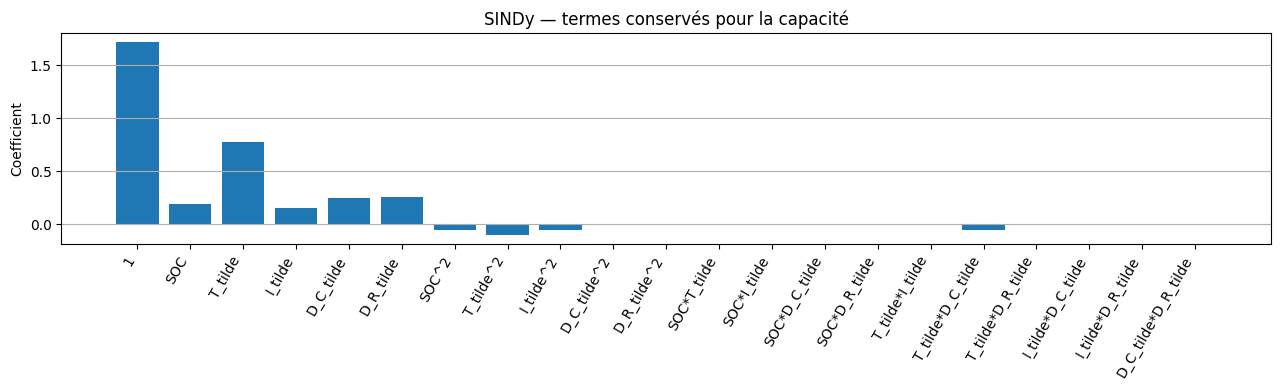

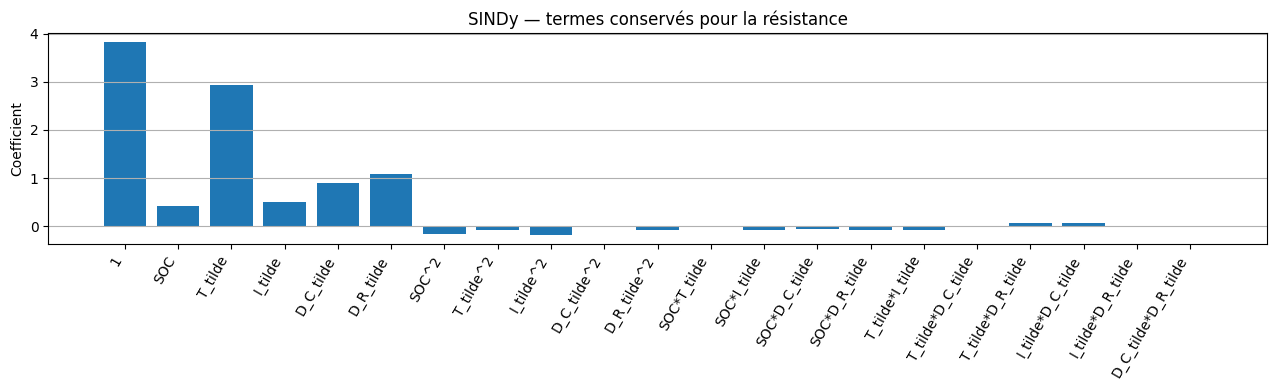

In [32]:
fig = plt.figure(
    figsize=(13, 4)
)

plt.bar(
    FEATURE_NAMES_RICH,
    coef_C_rich,
)

plt.xticks(
    rotation=60,
    ha="right",
)

plt.ylabel("Coefficient")
plt.title(
    "SINDy — termes conservés pour la capacité"
)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


fig = plt.figure(
    figsize=(13, 4)
)

plt.bar(
    FEATURE_NAMES_RICH,
    coef_R_rich,
)

plt.xticks(
    rotation=60,
    ha="right",
)

plt.ylabel("Coefficient")
plt.title(
    "SINDy — termes conservés pour la résistance"
)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()



# 8 jouer avec le seuil de parcimonie

Le paramètre principal de STLSQ est :

$$
\lambda
$$

- trop petit : beaucoup de termes sont conservés
- trop grand : des termes utiles disparaissent

On mesure pour plusieurs valeurs :

- le nombre de coefficients non nuls
- l'erreur sur des points jamais utilisés pour l'identification


In [45]:
#@title Influence du seuil — métriques et lois symboliques

THRESHOLDS = [
    0.0,
    0.005,
    0.01,
    0.02,
    0.05,
    0.10,
    0.20,
]

rows = []
laws_by_threshold = {}

for threshold in THRESHOLDS:

    cC = stlsq(
        Theta_train_rich,
        yC_train,
        threshold=threshold,
    )

    cR = stlsq(
        Theta_train_rich,
        yR_train,
        threshold=threshold,
    )

    predC = (
        Theta_test_rich
        @ cC
    )

    predR = (
        Theta_test_rich
        @ cR
    )

    rmseC, nrmseC, r2C = regression_metrics(
        yC_test,
        predC,
    )

    rmseR, nrmseR, r2R = regression_metrics(
        yR_test,
        predR,
    )

    rows.append({
        "threshold": threshold,
        "n_terms_C": int(
            np.sum(np.abs(cC) > 0)
        ),
        "NRMSE_C": nrmseC,
        "R2_C": r2C,
        "n_terms_R": int(
            np.sum(np.abs(cR) > 0)
        ),
        "NRMSE_R": nrmseR,
        "R2_R": r2R,
    })

    # Sauvegarde des lois
    laws_by_threshold[threshold] = {
        "C": cC,
        "R": cR,
    }


threshold_results = pd.DataFrame(
    rows
)

display(threshold_results)

,threshold,n_terms_C,NRMSE_C,R2_C,n_terms_R,NRMSE_R,R2_R
0,0.000,21,0.028661,0.999179,21,0.038132,0.998546
1,0.005,20,0.028710,0.999176,21,0.038132,0.998546
2,0.010,19,0.028766,0.999173,21,0.038132,0.998546
3,0.020,17,0.029017,0.999158,20,0.038150,0.998545
4,0.050,10,0.034168,0.998833,16,0.038742,0.998499
5,0.100,5,0.101538,0.989690,8,0.042437,0.998199
6,0.200,4,0.130324,0.983016,5,0.050293,0.997471


In [46]:
#@title Lois identifiées pour chaque seuil

rC_star = sp.Symbol(r"r_C^\star")
rR_star = sp.Symbol(r"r_R^\star")


for threshold in THRESHOLDS:

    coef_C = (
        laws_by_threshold[threshold]["C"]
    )

    coef_R = (
        laws_by_threshold[threshold]["R"]
    )

    expr_C = build_symbolic_law(
        coef_C,
        TERMS_RICH_SYM,
    )

    expr_R = build_symbolic_law(
        coef_R,
        TERMS_RICH_SYM,
    )

    print(
        f"Threshold = {threshold}"
    )

    print("Capacité :")
    display(
        sp.Eq(
            rC_star,
            expr_C,
        )
    )

    print("Résistance :")
    display(
        sp.Eq(
            rR_star,
            expr_R,
        )
    )

Threshold = 0.0
Capacité :


Eq(r_C^\star, -0.05227*SOC**2 + SOC*(-0.01235*\widetilde{D}_C - 0.03504*\widetilde{D}_R - 0.04372*\widetilde{I} - 0.003755*\widetilde{T} + 0.2301) - 0.03848*\widetilde{D}_C**2 + \widetilde{D}_C*(0.2892 - 0.02606*\widetilde{D}_R) - 0.03574*\widetilde{D}_R**2 + 0.3202*\widetilde{D}_R - 0.06174*\widetilde{I}**2 + \widetilde{I}*(0.02757*\widetilde{D}_C + 0.00601*\widetilde{D}_R + 0.1641) - 0.1007*\widetilde{T}**2 + \widetilde{T}*(-0.05576*\widetilde{D}_C - 0.01166*\widetilde{D}_R - 0.02021*\widetilde{I} + 0.7949) + 1.68)

Résistance :


Eq(r_R^\star, -0.1639*SOC**2 + SOC*(-0.06144*\widetilde{D}_C - 0.0808*\widetilde{D}_R - 0.07711*\widetilde{I} - 0.03357*\widetilde{T} + 0.4325) - 0.04937*\widetilde{D}_C**2 + \widetilde{D}_C*(0.9575 - 0.01857*\widetilde{D}_R) - 0.0834*\widetilde{D}_R**2 + 1.072*\widetilde{D}_R - 0.1797*\widetilde{I}**2 + \widetilde{I}*(0.06525*\widetilde{D}_C + 0.03016*\widetilde{D}_R + 0.4933) - 0.07066*\widetilde{T}**2 + \widetilde{T}*(0.04356*\widetilde{D}_C + 0.0715*\widetilde{D}_R - 0.0881*\widetilde{I} + 2.923) + 3.814)

Threshold = 0.005
Capacité :


...

Eq(r_R^\star, -0.1709*SOC**2 + 0.3269*SOC + 0.9044*\widetilde{D}_C + 0.9607*\widetilde{D}_R - 0.1745*\widetilde{I}**2 + 0.4822*\widetilde{I} + 2.901*\widetilde{T} + 3.858)

Threshold = 0.2
Capacité :


Eq(r_C^\star, 0.2374*\widetilde{D}_C + 0.2546*\widetilde{D}_R + 0.7237*\widetilde{T} + 1.832)

Résistance :


Eq(r_R^\star, 0.9039*\widetilde{D}_C + 0.9613*\widetilde{D}_R + 0.3105*\widetilde{I} + 2.902*\widetilde{T} + 3.999)


### À tester

Modifier le seuil et observer :

1. combien de termes restent
2. si les termes quadratiques disparaissent
3. à partir de quel seuil l'erreur augmente fortement

On cherche un compromis, précision + simplicité



# 10 Choisir une loi SINDy finale

On reprend la bibliothèque riche et un seuil réglable.

Le but est d'obtenir une loi suffisamment simple tout en conservant une bonne approximation de la Neural ODE.

Comme $D_C$ et $D_R$ sont maintenant des états du système, une petite erreur sur leur dépendance locale peut ensuite se propager pendant l'intégration.


In [41]:

FINAL_THRESHOLD = 0.1

coef_C_final = stlsq(
    Theta_train_rich,
    yC_train,
    threshold=FINAL_THRESHOLD,
)

coef_R_final = stlsq(
    Theta_train_rich,
    yR_train,
    threshold=FINAL_THRESHOLD,
)

pred_C_final = (
    Theta_test_rich
    @ coef_C_final
)

pred_R_final = (
    Theta_test_rich
    @ coef_R_final
)

print_law(
    "LOI FINALE — capacité",
    FEATURE_NAMES_RICH,
    coef_C_final,
)

print()

print_law(
    "LOI FINALE — résistance",
    FEATURE_NAMES_RICH,
    coef_R_final,
)

print()

print(
    "R² capacité =",
    regression_metrics(
        yC_test,
        pred_C_final,
    )[2],
)

print(
    "R² résistance =",
    regression_metrics(
        yR_test,
        pred_R_final,
    )[2],
)


LOI FINALE — capacité
  1              : +1.7630
  SOC            : +0.1319
  T_tilde        : +0.7228
  I_tilde        : +0.0000
  D_C_tilde      : +0.2375
  D_R_tilde      : +0.2547
  SOC^2          : +0.0000
  T_tilde^2      : +0.0000
  I_tilde^2      : +0.0000
  D_C_tilde^2    : +0.0000
  D_R_tilde^2    : +0.0000
  SOC*T_tilde    : +0.0000
  SOC*I_tilde    : +0.0000
  SOC*D_C_tilde  : +0.0000
  SOC*D_R_tilde  : +0.0000
  T_tilde*I_tilde : +0.0000
  T_tilde*D_C_tilde : +0.0000
  T_tilde*D_R_tilde : +0.0000
  I_tilde*D_C_tilde : +0.0000
  I_tilde*D_R_tilde : +0.0000
  D_C_tilde*D_R_tilde : +0.0000

LOI FINALE — résistance
  1              : +3.8578
  SOC            : +0.3269
  T_tilde        : +2.9009
  I_tilde        : +0.4822
  D_C_tilde      : +0.9044
  D_R_tilde      : +0.9607
  SOC^2          : -0.1709
  T_tilde^2      : +0.0000
  I_tilde^2      : -0.1745
  D_C_tilde^2    : +0.0000
  D_R_tilde^2    : +0.0000
  SOC*T_tilde    : +0.0000
  SOC*I_tilde    : +0.0000
  SOC*D_C_tilde  

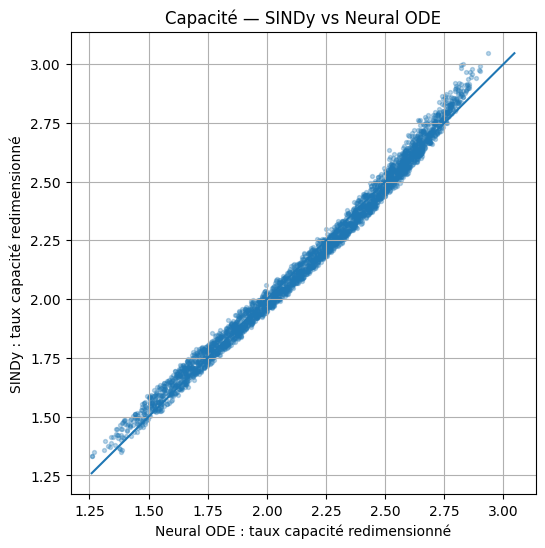

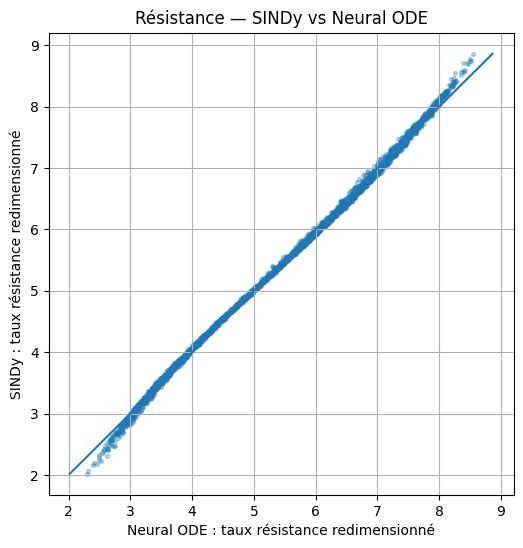

In [42]:
fig = plt.figure(
    figsize=(6, 6)
)

plt.scatter(
    yC_test,
    pred_C_final,
    s=8,
    alpha=0.3,
)

vmin = min(
    yC_test.min(),
    pred_C_final.min(),
)

vmax = max(
    yC_test.max(),
    pred_C_final.max(),
)

plt.plot(
    [vmin, vmax],
    [vmin, vmax],
)

plt.xlabel("Neural ODE : taux capacité redimensionné")
plt.ylabel("SINDy : taux capacité redimensionné")
plt.title("Capacité — SINDy vs Neural ODE")
plt.grid(True)
plt.show()


fig = plt.figure(
    figsize=(6, 6)
)

plt.scatter(
    yR_test,
    pred_R_final,
    s=8,
    alpha=0.3,
)

vmin = min(
    yR_test.min(),
    pred_R_final.min(),
)

vmax = max(
    yR_test.max(),
    pred_R_final.max(),
)

plt.plot(
    [vmin, vmax],
    [vmin, vmax],
)

plt.xlabel("Neural ODE : taux résistance redimensionné")
plt.ylabel("SINDy : taux résistance redimensionné")
plt.title("Résistance — SINDy vs Neural ODE")
plt.grid(True)
plt.show()


# 11 Comparer les trajectoires sur 7 jours

Maintenant que le taux dépend de $D_C$ et $D_R$, on ne peut plus calculer une fois le champ puis faire une simple somme cumulée.

Il faut intégrer récursivement :

$$
D_{k+1}
=
D_k
+
\left.
\frac{dD}{dQ}
\right|_{D_k}
\Delta Q_k
$$

Le nouvel état $D_{k+1}$ est donc réinjecté dans la loi au pas suivant.

On construit un nouveau scénario synthétique de 7 jours et on compare neural ode, sindy et la vraie loi

Pour isoler la structure de cyclage, on ne rajoute pas ici de terme calendaire.


In [47]:
DT_SCENARIO = 300.0

t_scenario = np.arange(
    0.0,
    7.0 * 86400.0 + DT_SCENARIO,
    DT_SCENARIO,
)

I_scenario = (
    25.0
    * np.sin(
        2.0
        * np.pi
        * t_scenario
        / 86400.0
    )
    + 10.0
    * np.sin(
        2.0
        * np.pi
        * t_scenario
        / (6.0 * 3600.0)
    )
)

T_scenario = (
    25.0
    + 6.0
    * np.sin(
        2.0
        * np.pi
        * t_scenario
        / 86400.0
        - 0.7
    )
)

C0_SCENARIO = 250.0
R0_REF = 0.8

SOC0_SCENARIO = 0.65
DC0_SCENARIO = 0.010
DR0_SCENARIO = 0.020


def sindy_rates_one(
    soc,
    temp,
    current,
    D_C,
    D_R,
):
    x = np.array([[
        soc,
        (temp - 25.0) / 20.0,
        abs(current) / 200.0,
        D_C / D_C_REF,
        D_R / D_R_REF,
    ]])

    theta = library_rich(
        x
    )[0]

    rate_C_scaled = (
        theta
        @ coef_C_final
    )

    rate_R_scaled = (
        theta
        @ coef_R_final
    )

    return np.array([
        rate_C_scaled / DISPLAY_RATE_SCALE,
        rate_R_scaled / DISPLAY_RATE_SCALE,
    ])


def nn_rates_one(
    soc,
    temp,
    current,
    D_C,
    D_R,
):
    return np.asarray(
        ageing_rates_one(
            model,
            soc,
            temp,
            current,
            D_C,
            D_R,
        )
    )


def integrate_damage_scenario(
    rate_function,
):
    n = len(
        t_scenario
    )

    SOC = np.zeros(n)
    D_C = np.zeros(n)
    D_R = np.zeros(n)

    SOC[0] = SOC0_SCENARIO
    D_C[0] = DC0_SCENARIO
    D_R[0] = DR0_SCENARIO

    for k in range(
        n - 1
    ):
        rates = rate_function(
            SOC[k],
            T_scenario[k],
            I_scenario[k],
            D_C[k],
            D_R[k],
        )

        dQ = (
            abs(I_scenario[k])
            * DT_SCENARIO
            / 3600.0
        )

        D_C[k + 1] = (
            D_C[k]
            + rates[0]
            * dQ
        )

        D_R[k + 1] = (
            D_R[k]
            + rates[1]
            * dQ
        )

        Cmax_k = (
            C0_SCENARIO
            * (
                1.0
                - D_C[k]
            )
        )

        SOC[k + 1] = np.clip(
            SOC[k]
            - I_scenario[k]
            * DT_SCENARIO
            / (
                3600.0
                * Cmax_k
            ),
            0.1,
            0.95,
        )

    return SOC, D_C, D_R


SOC_nn, D_C_nn, D_R_nn = (
    integrate_damage_scenario(
        nn_rates_one
    )
)

SOC_sindy, D_C_sindy, D_R_sindy = (
    integrate_damage_scenario(
        sindy_rates_one
    )
)

C_nn = (
    C0_SCENARIO
    * (
        1.0
        - D_C_nn
    )
)

C_sindy = (
    C0_SCENARIO
    * (
        1.0
        - D_C_sindy
    )
)

R_nn = (
    R0_REF
    * (
        1.0
        + D_R_nn
    )
)

R_sindy = (
    R0_REF
    * (
        1.0
        + D_R_sindy
    )
)


In [48]:
# ============================================================
# VRAIE LOI SYNTHÉTIQUE DU TP2
# ============================================================

true_law = metadata[
    "true_synthetic_law"
]

kC_true = float(
    true_law["kC_true"]
)

kR_true = float(
    true_law["kR_true"]
)


def true_rates_one(
    soc,
    temp,
    current,
    D_C,
    D_R,
):
    T_tilde = (
        temp - 25.0
    ) / 20.0

    I_tilde = (
        abs(current)
        / 200.0
    )

    D_C_tilde = (
        D_C
        / D_C_REF
    )

    D_R_tilde = (
        D_R
        / D_R_REF
    )

    rate_C = (
        kC_true
        * (
            1.0
            + 1.0 * soc
            + 0.5 * T_tilde
            + 0.5 * I_tilde
            + 0.5 * D_C_tilde
        )
    )

    rate_R = (
        kR_true
        * (
            1.0
            + 0.5 * soc
            + 0.5 * T_tilde
            + 1.0 * I_tilde
            + 0.5 * D_R_tilde
        )
    )

    return np.array([
        rate_C,
        rate_R,
    ])


SOC_true, D_C_true_scenario, D_R_true_scenario = (
    integrate_damage_scenario(
        true_rates_one
    )
)

C_true_scenario = (
    C0_SCENARIO
    * (
        1.0
        - D_C_true_scenario
    )
)

R_true_scenario = (
    R0_REF
    * (
        1.0
        + D_R_true_scenario
    )
)

print(
    "Cmax vrai final :",
    f"{C_true_scenario[-1]:.4f} Ah"
)

print(
    "R0 vrai final :",
    f"{R_true_scenario[-1]:.6f} Ohm"
)


Cmax vrai final : 234.4366 Ah
R0 vrai final : 0.918914 Ohm


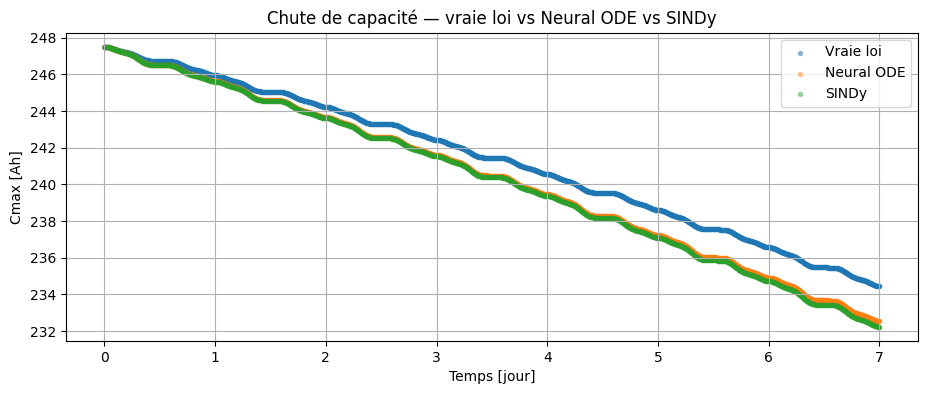

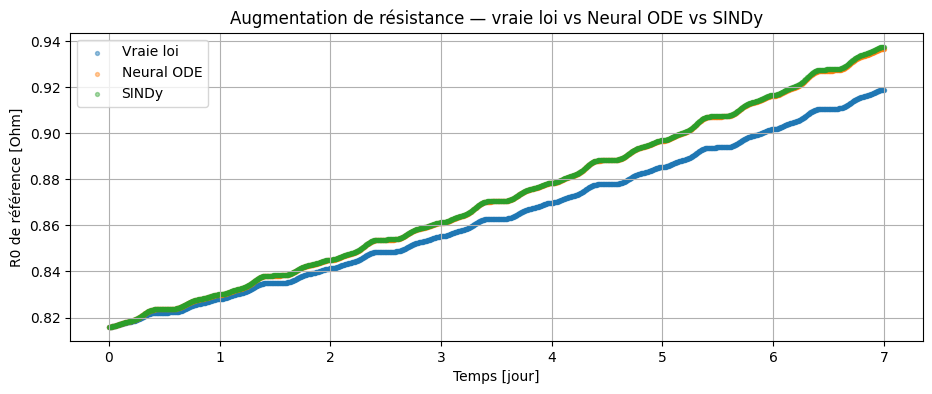

CAPACITÉ
Vraie loi     : 234.4366 Ah
Neural ODE    : 232.5326 Ah
SINDy         : 232.2282 Ah

RÉSISTANCE
Vraie loi     : 0.918914 Ohm
Neural ODE    : 0.936687 Ohm
SINDy         : 0.937507 Ohm

Erreur Neural ODE / vraie loi sur C : -1.9040 Ah
Erreur SINDy / vraie loi sur C      : -2.2084 Ah
Erreur Neural ODE / vraie loi sur R : +0.017773 Ohm
Erreur SINDy / vraie loi sur R      : +0.018593 Ohm


In [49]:
# ============================================================
# CAPACITÉ
# ============================================================

fig = plt.figure(
    figsize=(11, 4)
)

plt.scatter(
    t_scenario / 86400.0,
    C_true_scenario,
    s=8,
    alpha=0.45,
    label="Vraie loi",
)

plt.scatter(
    t_scenario / 86400.0,
    C_nn,
    s=8,
    alpha=0.40,
    label="Neural ODE",
)

plt.scatter(
    t_scenario / 86400.0,
    C_sindy,
    s=8,
    alpha=0.40,
    label="SINDy",
)

plt.xlabel("Temps [jour]")
plt.ylabel("Cmax [Ah]")

plt.title(
    "Chute de capacité — "
    "vraie loi vs Neural ODE vs SINDy"
)

plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# RÉSISTANCE
# ============================================================

fig = plt.figure(
    figsize=(11, 4)
)

plt.scatter(
    t_scenario / 86400.0,
    R_true_scenario,
    s=8,
    alpha=0.45,
    label="Vraie loi",
)

plt.scatter(
    t_scenario / 86400.0,
    R_nn,
    s=8,
    alpha=0.40,
    label="Neural ODE",
)

plt.scatter(
    t_scenario / 86400.0,
    R_sindy,
    s=8,
    alpha=0.40,
    label="SINDy",
)

plt.xlabel("Temps [jour]")
plt.ylabel("R0 de référence [Ohm]")

plt.title(
    "Augmentation de résistance — "
    "vraie loi vs Neural ODE vs SINDy"
)

plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# ERREURS FINALES
# ============================================================

print("CAPACITÉ")
print(
    "Vraie loi     :",
    f"{C_true_scenario[-1]:.4f} Ah"
)
print(
    "Neural ODE    :",
    f"{C_nn[-1]:.4f} Ah"
)
print(
    "SINDy         :",
    f"{C_sindy[-1]:.4f} Ah"
)

print()

print("RÉSISTANCE")
print(
    "Vraie loi     :",
    f"{R_true_scenario[-1]:.6f} Ohm"
)
print(
    "Neural ODE    :",
    f"{R_nn[-1]:.6f} Ohm"
)
print(
    "SINDy         :",
    f"{R_sindy[-1]:.6f} Ohm"
)

print()

print(
    "Erreur Neural ODE / vraie loi sur C :",
    f"{C_nn[-1] - C_true_scenario[-1]:+.4f} Ah"
)

print(
    "Erreur SINDy / vraie loi sur C      :",
    f"{C_sindy[-1] - C_true_scenario[-1]:+.4f} Ah"
)

print(
    "Erreur Neural ODE / vraie loi sur R :",
    f"{R_nn[-1] - R_true_scenario[-1]:+.6f} Ohm"
)

print(
    "Erreur SINDy / vraie loi sur R      :",
    f"{R_sindy[-1] - R_true_scenario[-1]:+.6f} Ohm"
)

# 12 loi synthétique du TP précédent


La loi utilisée pour construire les données synthétiques avait volontairement une structure affine en variables normalisées.

Pour éviter d'afficher des constantes numériques très petites, on compare ici seulement la forme de la loi en divisant chaque taux par son coefficient global.

On définit :

$$
g_C
=
\frac{1}{k_C}
\frac{dD_C}{dQ}
\qquad
g_R
=
\frac{1}{k_R}
\frac{dD_R}{dQ}
$$

La vraie loi de capacité est alors :

$$
\boxed{
g_C
=
1
+
SOC
+
0.5\widetilde T
+
0.5\widetilde I
+
0.5\widetilde D_C
}
$$

et la vraie loi de résistance :

$$
\boxed{
g_R
=
1
+
0.5SOC
+
0.5\widetilde T
+
\widetilde I
+
0.5\widetilde D_R
}
$$

avec :

$$
\widetilde D_C
=
\frac{D_C}{D_{C,\mathrm{ref}}}
\qquad
\widetilde D_R
=
\frac{D_R}{D_{R,\mathrm{ref}}}
$$

Avec la bibliothèque minimale commune

$$
[
1,\,
SOC,\,
\widetilde T,\,
\widetilde I,\,
\widetilde D_C,\,
\widetilde D_R
],
$$

les coefficients relatifs théoriques sont donc :

$$
[1,\;1,\;0.5,\;0.5,\;0.5,\;0]
$$

pour la capacité, et :

$$
[1,\;0.5,\;0.5,\;1,\;0,\;0.5]
$$

pour la résistance.


In [51]:
def relative_coefficients(
    coef,
):
    if np.abs(coef[0]) < 1e-14:
        return np.full_like(
            coef,
            np.nan,
        )

    return (
        coef
        / coef[0]
    )


relative_C = relative_coefficients(
    coef_C_lstsq
)

relative_R = relative_coefficients(
    coef_R_lstsq
)

truth_C = np.array([
    1.0,
    1.0,
    0.5,
    0.5,
    0.5,
    0.0,
])

truth_R = np.array([
    1.0,
    0.5,
    0.5,
    1.0,
    0.0,
    0.5,
])

comparison_truth = pd.DataFrame({
    "terme": FEATURE_NAMES_SIMPLE,
    "C théorique": truth_C,
    "C identifié": relative_C,
    "R théorique": truth_R,
    "R identifié": relative_R,
})

comparison_truth


,terme,C théorique,C identifié,R théorique,R identifié
0,1,1.0,1.000000,1.0,1.000000
1,SOC,1.0,0.075894,0.5,0.037802
2,T_tilde,0.5,0.421500,0.5,0.739438
3,I_tilde,0.5,0.054608,1.0,0.078722
4,D_C_tilde,0.5,0.138185,0.0,0.230458
5,D_R_tilde,0.0,0.147926,0.5,0.245102
